### Análisis Exploratorio de Datos (EDA)

#### El objetivo de este análisis es comprender las características principales de las estaciones de esquí incluidas en el dataset, identificar patrones relevantes y obtener insights que permitan responder preguntas de negocio mediante un dashboard en Power BI.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/ski_resorts_powerbi.csv")
df.head()

,URL,Valoración,Estación,Km freeride,Continente,País,Provincia/Estado,Altitud,Km fáciles,Km intermedios,...,Latitud,Longitud,Km totales,Categoría tamaño,% Pistas fáciles,% Pistas intermedias,% Pistas difíciles,Perfil recomendado,Perfil freeride,Precio por km
0,http://www.skiresort.info/ski-resort/kitzski-k...,4.9,KitzSki – Kitzbühel/Kirchberg,45.0,Europe,Austria,Tyrol (Tirol),2000.0,101.0,61.0,...,47.516231,14.550072,179.0,Muy grande,56.424581,34.078212,9.497207,Principiante,Para amantes del freeride,0.31
1,http://www.skiresort.info/ski-resort/ischglsam...,4.8,Ischgl/Samnaun – Silvretta Arena,15.0,Europe,Austria,Tyrol (Tirol),2872.0,47.0,142.0,...,47.516231,14.550072,238.0,Muy grande,19.747899,59.663866,20.588235,Intermedio,Freeride avanzado,0.22
2,http://www.skiresort.info/ski-resort/skiwelt-w...,4.8,SkiWelt Wilder Kaiser-Brixental,26.0,Europe,Austria,Tyrol (Tirol),1957.0,122.0,129.0,...,47.516231,14.550072,284.0,Muy grande,42.957746,45.422535,11.619718,Equilibrada,Freeride avanzado,0.17
3,http://www.skiresort.info/ski-resort/st-antons...,4.8,Ski Arlberg,200.0,Europe,Austria,Tyrol (Tirol),2811.0,132.0,123.0,...,47.516231,14.550072,305.0,Muy grande,43.278689,40.327869,16.393443,Equilibrada,Para amantes del freeride,0.17
4,http://www.skiresort.info/ski-resort/serfaus-f...,4.8,Serfaus-Fiss-Ladis,28.0,Europe,Austria,Tyrol (Tirol),2820.0,47.0,123.0,...,47.516231,14.550072,198.0,Muy grande,23.737374,62.121212,14.141414,Intermedio,Freeride avanzado,0.26


In [3]:
import matplotlib.pyplot as plt

### Distribución de estaciones por país

In [4]:
df.shape

df["País"].nunique()

df["Continente"].value_counts()

df["País"].value_counts().head(10)

País
Germany           715
Japan             597
USA               521
Austria           433
Switzerland       333
Czech Republic    301
Italy             291
Canada            289
Poland            254
France            251
Name: count, dtype: int64

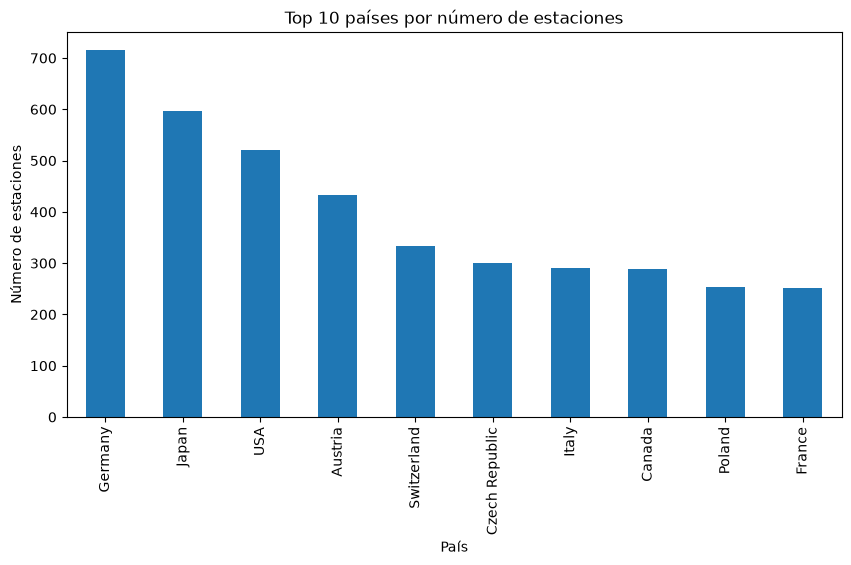

In [5]:
top10 = df["País"].value_counts().head(10)

plt.figure(figsize=(10,5))
top10.plot(kind="bar")

plt.title("Top 10 países por número de estaciones")
plt.ylabel("Número de estaciones")
plt.xlabel("País")

plt.show()

#### Alemania es el país con mayor número de estaciones de esquí del dataset, seguido por Japón y Estados Unidos. Aunque los países alpinos concentran una parte importante de la oferta mundial, destacan mercados menos conocidos como Japón, que ocupa la segunda posición en número de estaciones.

In [6]:
df["Categoría tamaño"].value_counts()

Categoría tamaño
Muy pequeña    3593
Pequeña        1291
Mediana         423
Grande          121
Muy grande       41
Name: count, dtype: int64

#### La mayoría de estaciones del dataset son de tamaño muy pequeño o pequeño. Esto indica que el mercado está formado principalmente por estaciones locales, mientras que los grandes dominios esquiables representan una proporción mucho menor.

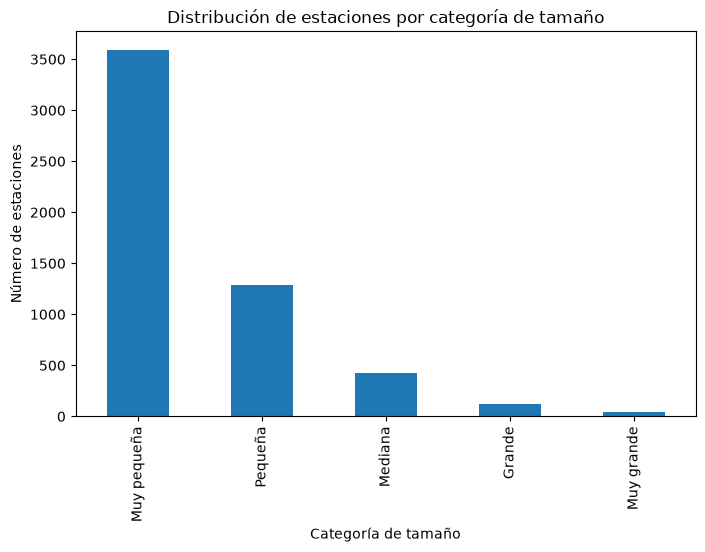

In [7]:
tamano = df["Categoría tamaño"].value_counts()

plt.figure(figsize=(8,5))
tamano.plot(kind="bar")

plt.title("Distribución de estaciones por categoría de tamaño")
plt.xlabel("Categoría de tamaño")
plt.ylabel("Número de estaciones")

plt.show()

In [8]:
pd.crosstab(df["País"], df["Categoría tamaño"]).loc[
    df["País"].value_counts().head(10).index
]

Categoría tamaño,Grande,Mediana,Muy grande,Muy pequeña,Pequeña
País,,,,,
Germany,0,7,0,656,52
Japan,1,18,0,422,156
USA,40,77,7,212,185
Austria,16,51,6,234,126
Switzerland,11,64,6,166,86
Czech Republic,0,1,0,268,32
Italy,11,43,3,117,117
Canada,13,24,1,151,100
Poland,0,1,0,239,14


In [11]:
pip install plotly

  Using cached plotly-6.8.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
Using cached plotly-6.8.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhal


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import plotly.express as px

fig = px.scatter_geo(
    df,
    lat="Latitud",
    lon="Longitud",
    color="Categoría tamaño",
    hover_name="Estación",
    hover_data=["País", "Km totales"],
    title="Distribución mundial de estaciones de esquí"
)

fig.show()

In [13]:
import plotly.express as px

fig = px.scatter(
    df[df["Precio forfait adulto"] > 0],
    x="Km totales",
    y="Precio forfait adulto",
    color="Categoría tamaño",
    hover_name="Estación",
    trendline="ols",
    title="Relación entre tamaño de la estación y precio del forfait"
)

fig.show()

ModuleNotFoundError: No module named 'statsmodels'

In [15]:
fig = px.box(
    df,
    x="Categoría tamaño",
    y="Km freeride",
    title="Distribución de kilómetros freeride según tamaño de estación"
)

fig.show()

In [16]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------  9.4/9.6 MB 53.4 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 40.2 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -------------- ------------------------- 13.9/37.3 MB 69.9 MB/s eta 0:00:01
   ----------------------------- ---------- 27.5/37.3 MB 66.0 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 67.2 MB/s eta 0:00:01
   ---------------------------------------- 37.3/37.3 MB 49.3 MB/s  0:00:00

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   -


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import plotly.express as px

fig = px.scatter(
    df[df["Precio forfait adulto"] > 0],
    x="Km totales",
    y="Precio forfait adulto",
    color="Categoría tamaño",
    hover_name="Estación",
    trendline="ols",
    title="Relación entre tamaño de la estación y precio del forfait"
)

fig.show()

In [19]:
df["Moneda"].value_counts()

Moneda
European Euro              2076
Japanese Yen                597
US Dollar                   522
Swiss Franc                 336
Czech koruna                301
Canadian Dollar             289
Polish zloty                254
Chinese Yuan                133
Swedish krona               118
Norwegian krone             112
Russian ruble                93
Romanian leu                 93
UK Pound                     80
Ukrainian hryvnia            48
New Zealand Dollar           40
Turkish lira                 36
Serbian dinar                25
Indian rupee                 22
Iranian rial                 21
Kyrgyzstani som              21
South Korean won             21
Bulgarian Lev                20
Danish Krone                 19
Argentine Peso               19
Chiliean Peso                17
Bosnia convertible mark      16
Australian dollar            15
Hungarian forint             14
Icelandic krona              11
Croatian Kuna                10
Macedonian denar              8
M

In [20]:
df.groupby("Moneda")["Precio forfait adulto"].describe()

,count,mean,std,min,25%,50%,75%,max
Moneda,,,,,,,,
Albanian Lek,2.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0
Algerian Dinar,1.0,0.000000,NaN,0.0,0.00,0.0,0.00,0.0
Argentine Peso,19.0,596.947368,539.383236,0.0,0.00,500.0,1146.00,1330.0
Armenian Dram,3.0,3666.666667,6350.852961,0.0,0.00,0.0,5500.00,11000.0
Australian dollar,15.0,61.000000,54.472798,0.0,0.00,70.0,114.00,129.0
Azerbaijani manat,2.0,13.000000,18.384776,0.0,6.50,13.0,19.50,26.0
Bahraini Dinar,1.0,0.000000,NaN,0.0,0.00,0.0,0.00,0.0
Belarusian Ruble,4.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0
Bosnia convertible mark,16.0,16.500000,13.976170,0.0,0.00,17.5,25.50,45.0


In [21]:
df["Moneda"].nunique()

60

In [22]:
df["Moneda"].value_counts(normalize=True).head(15) * 100

Moneda
European Euro         37.959408
Japanese Yen          10.916072
US Dollar              9.544707
Swiss Franc            6.143719
Czech koruna           5.503748
Canadian Dollar        5.284330
Polish zloty           4.644359
Chinese Yuan           2.431889
Swedish krona          2.157616
Norwegian krone        2.047906
Russian ruble          1.700494
Romanian leu           1.700494
UK Pound               1.462790
Ukrainian hryvnia      0.877674
New Zealand Dollar     0.731395
Name: proportion, dtype: float64

In [23]:
tipos_cambio_eur = {
    "European Euro": 1.00,
    "US Dollar": 0.87,
    "Japanese Yen": 0.0054,
    "Swiss Franc": 1.08,
    "Czech koruna": 0.041,
    "Canadian Dollar": 0.64,
    "Polish zloty": 0.233,
    "Chinese Yuan": 0.122,
    "Swedish krona": 0.091,
    "Norwegian krone": 0.086,
    "Russian ruble": 0.011,
    "Romanian leu": 0.191,
    "UK Pound": 1.16,
    "Ukrainian hryvnia": 0.021,
    "New Zealand Dollar": 0.52
}

In [24]:
df["Precio forfait EUR"] = (
    df["Precio forfait adulto"] *
    df["Moneda"].map(tipos_cambio_eur)
).round(2)

In [25]:
df["Precio forfait EUR"].isna().sum()

np.int64(377)

In [26]:
df[df["Precio forfait EUR"].isna()]["Moneda"].value_counts()

Moneda
Turkish lira               36
Serbian dinar              25
Indian rupee               22
Iranian rial               21
Kyrgyzstani som            21
South Korean won           21
Bulgarian Lev              20
Danish Krone               19
Argentine Peso             19
Chiliean Peso              17
Bosnia convertible mark    16
Australian dollar          15
Hungarian forint           14
Icelandic krona            11
Croatian Kuna              10
Macedonian denar            8
Moroccan Dirham             7
Lebanese pound              7
Georgian Lari               6
United Arab Emerites        6
Turkmenistani Manat         5
Kazakhstani tenge           5
South African rand          4
Uzbekistani Som             4
Belarusian Ruble            4
Armenian Dram               3
Malaysian Ringgit           3
North Korean Won            3
Pakistani Rupee             3
Albanian Lek                2
Iraqi Dinar                 2
Qatari Riyal                2
Israeli new shekel          2
Aze

In [27]:
tipos_cambio_eur.update({
    "Turkish lira": 0.022,
    "Serbian dinar": 0.0085,
    "Indian rupee": 0.010,
    "Iranian rial": 0.000021,
    "Kyrgyzstani som": 0.010,
    "South Korean won": 0.00063,
    "Bulgarian Lev": 0.511,
    "Danish Krone": 0.134,
    "Argentine Peso": 0.00080,
    "Chiliean Peso": 0.00095,
    "Bosnia convertible mark": 0.511,
    "Australian dollar": 0.57,
    "Hungarian forint": 0.0025,
    "Icelandic krona": 0.0070,
    "Croatian Kuna": 0.133,
    "Macedonian denar": 0.016,
    "Moroccan Dirham": 0.095,
    "Lebanese pound": 0.000010,
    "Georgian Lari": 0.32,
    "United Arab Emerites": 0.24,
    "Turkmenistani Manat": 0.25,
    "Kazakhstani tenge": 0.0017,
    "South African rand": 0.047,
    "Uzbekistani Som": 0.000068,
    "Egyptian Pound": 0.017,
    "Namibian Dollar": 0.047,
    "Mongolian togrog": 0.00026,
    "Singapore Dollar": 0.64
})

In [28]:
df["Precio forfait EUR"] = (
    df["Precio forfait adulto"] *
    df["Moneda"].map(tipos_cambio_eur)
).round(2)

In [29]:
df["Precio forfait EUR"].isna().sum()

np.int64(34)

In [30]:
df[df["Precio forfait EUR"].isna()]["Moneda"].value_counts()

Moneda
Belarusian Ruble      4
Armenian Dram         3
Malaysian Ringgit     3
North Korean Won      3
Pakistani Rupee       3
Albanian Lek          2
Iraqi Dinar           2
Qatari Riyal          2
Israeli new shekel    2
Azerbaijani manat     2
unknown               2
Mexican Peso          1
Algerian Dinar        1
Nepalese Rupee        1
Peruvian Sol          1
Thai Baht             1
Bahraini Dinar        1
Name: count, dtype: int64

In [31]:
tipos_cambio_eur.update({
    "Belarusian Ruble": 0.27,
    "Armenian Dram": 0.0022,
    "Malaysian Ringgit": 0.20,
    "North Korean Won": 0.0010,  # aproximación
    "Pakistani Rupee": 0.0031,
    "Albanian Lek": 0.010,
    "Iraqi Dinar": 0.00070,
    "Qatari Riyal": 0.24,
    "Israeli new shekel": 0.25,
    "Azerbaijani manat": 0.52,
    "Mexican Peso": 0.046,
    "Algerian Dinar": 0.0068,
    "Nepalese Rupee": 0.0063,
    "Peruvian Sol": 0.23,
    "Thai Baht": 0.026,
    "Bahraini Dinar": 2.30
})

In [32]:
df["Precio forfait EUR"] = (
    df["Precio forfait adulto"] *
    df["Moneda"].map(tipos_cambio_eur)
).round(2)

df["Precio forfait EUR"].isna().sum()

np.int64(2)

In [33]:
df[df["Precio forfait EUR"].isna()]["Moneda"].value_counts()

Moneda
unknown    2
Name: count, dtype: int64

In [34]:
df["Precio por km EUR"] = (
    df["Precio forfait EUR"] / df["Total Kms"]
).round(2)

df["Precio por km EUR"] = df["Precio por km EUR"].replace([np.inf, -np.inf], np.nan)

KeyError: 'Total Kms'

In [35]:
df["Precio por km EUR"] = (
    df["Precio forfait EUR"] / df["Km totales"]
).round(2)

df["Precio por km EUR"] = df["Precio por km EUR"].replace([np.inf, -np.inf], np.nan)

In [ ]:
df[["Precio forfait EUR", "Km totales", "Precio por km EUR"]].head()